In [18]:
# GRadient Boosting Algorithm: build models in sequence, each correcting the errors of the previous one
# Wisdom of CrOWDS with some weight given to each model
# Eg. Build the first regression model, calculate errors, build the second model on errors, and so on...
# Each new model corrects the errors of the previous model

# Hyperparameters in GBM
# No of iterations (n)
# Learning rate (shrinkage ~ p): makes the learning process slow, p: [0.0001 : 1]
# Size of each tree (depth)

import pandas as pd
import matplotlib.pyplot as plt

pets_data = pd.read_csv(r'datasets/adoption.csv')

pets_data.head()


,Sr_No,cust_age,adopted_pet
0,1,18,1
1,2,14,1
2,3,22,0
3,4,39,0
4,5,55,1


In [19]:
X =pets_data[["cust_age"]]
y=h=pets_data['adopted_pet']
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import f1_score



SSE :  14.149375035688564
Accuracy :  0.782608695652174
SSE :  11.27995313978165
Accuracy :  0.782608695652174
SSE :  4.599020242391308
Accuracy :  1.0
SSE :  3.169524322866381
Accuracy :  1.0
SSE :  2.255280817806731
Accuracy :  1.0
SSE :  1.0451902708931387
Accuracy :  1.0
SSE :  0.8158423973000427
Accuracy :  1.0
SSE :  0.63466418158891
Accuracy :  1.0
SSE :  0.26766575694418226
Accuracy :  1.0
SSE :  0.21421884089660634
Accuracy :  1.0
SSE :  0.17335936100623117
Accuracy :  1.0
SSE :  0.07016056855230614
Accuracy :  1.0
SSE :  0.05653098101827333
Accuracy :  1.0
SSE :  0.046786716216881706
Accuracy :  1.0
SSE :  0.01853947509919185
Accuracy :  1.0
SSE :  0.01493340923621501
Accuracy :  1.0
SSE :  0.012535601331849248
Accuracy :  1.0
SSE :  0.004914886458223169
Accuracy :  1.0
SSE :  0.003945378085545501
Accuracy :  1.0
SSE :  0.0033439626063109596
Accuracy :  1.0


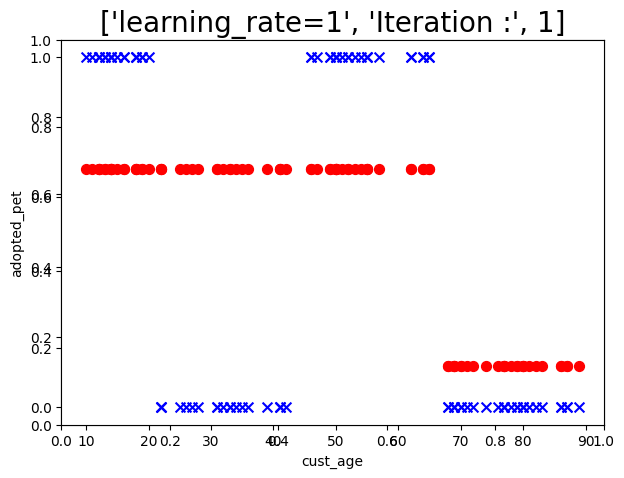

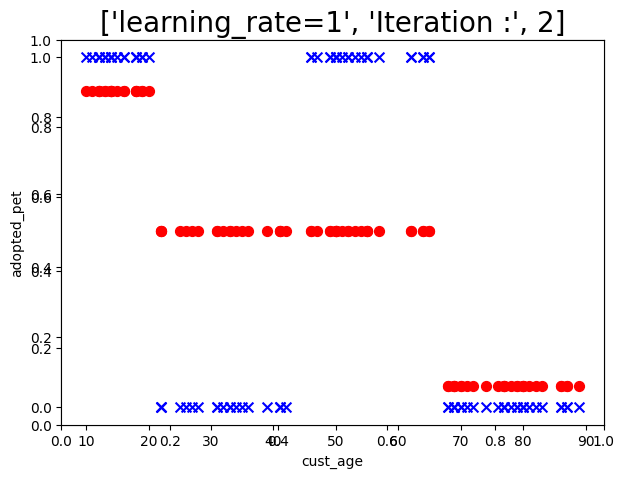

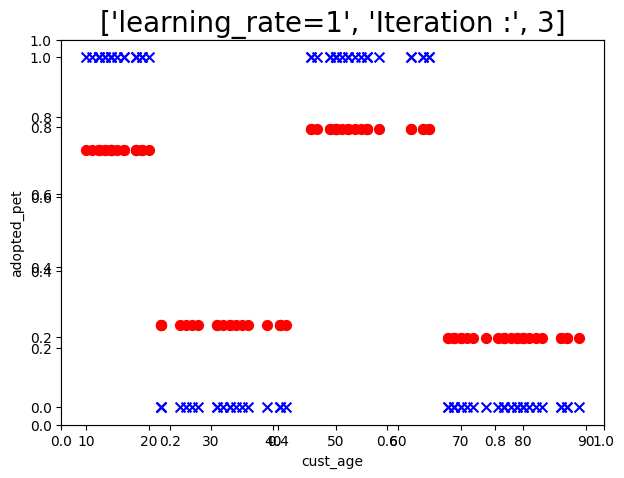

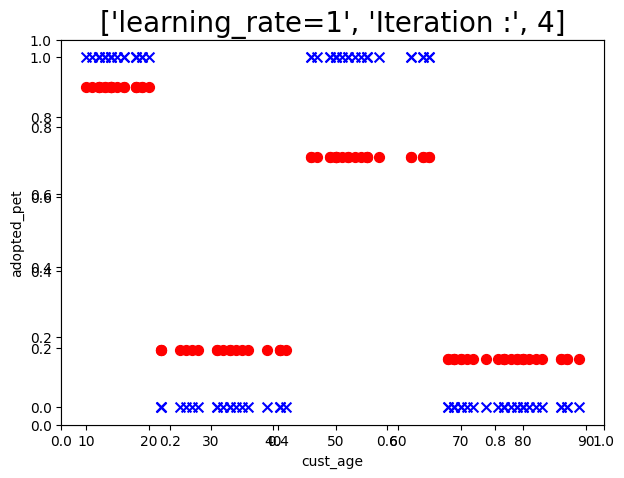

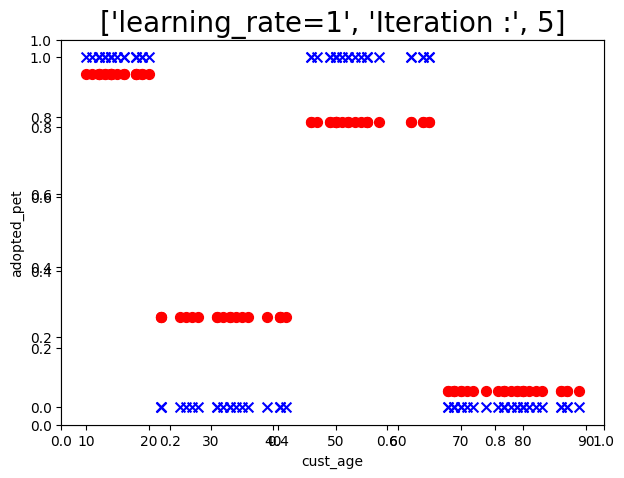

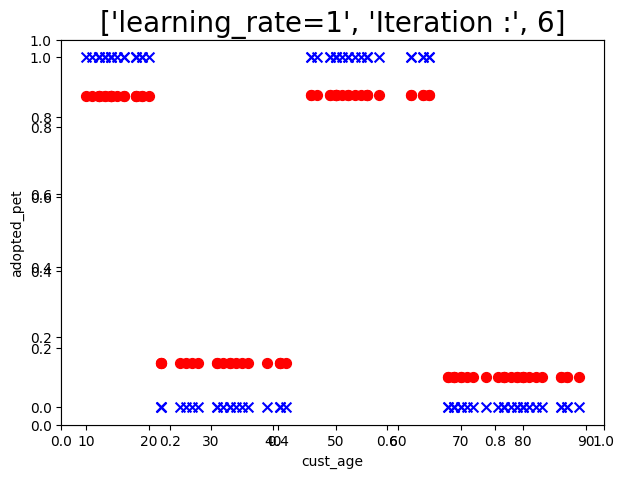

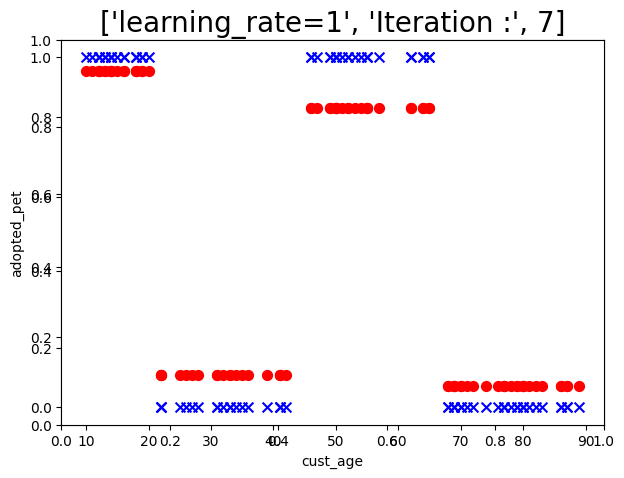

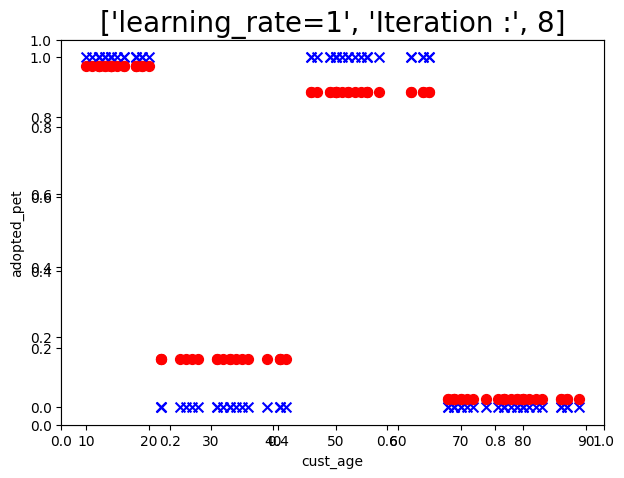

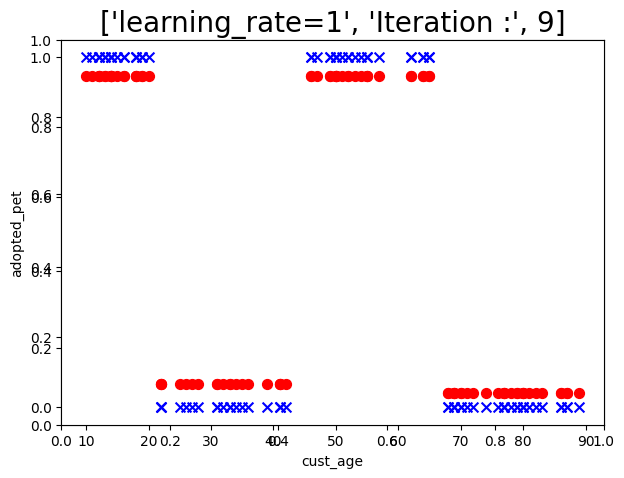

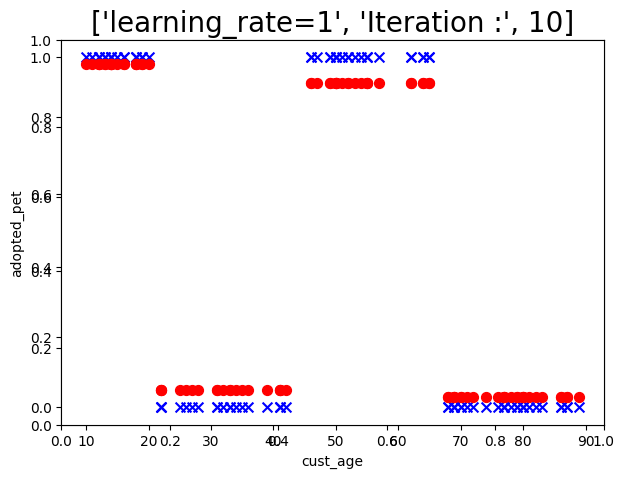

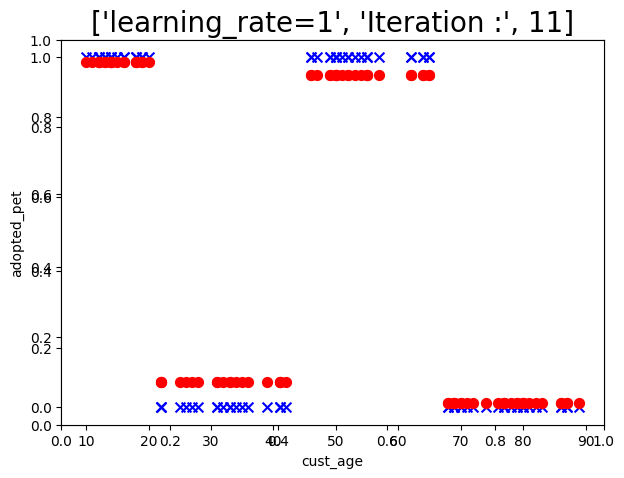

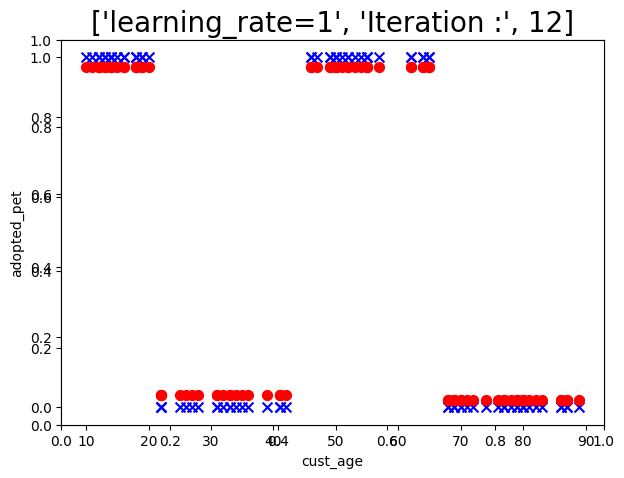

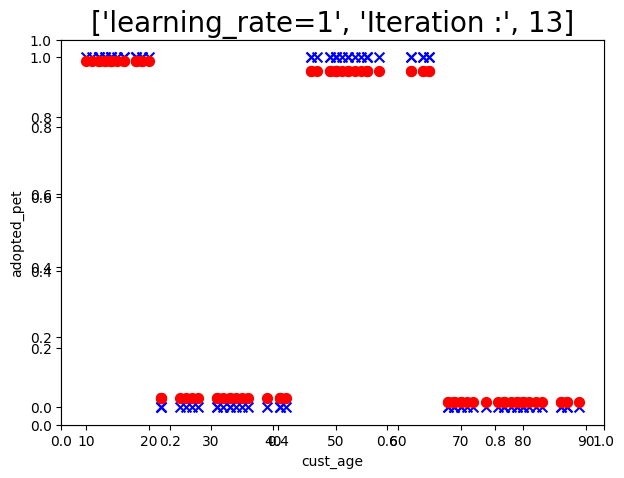

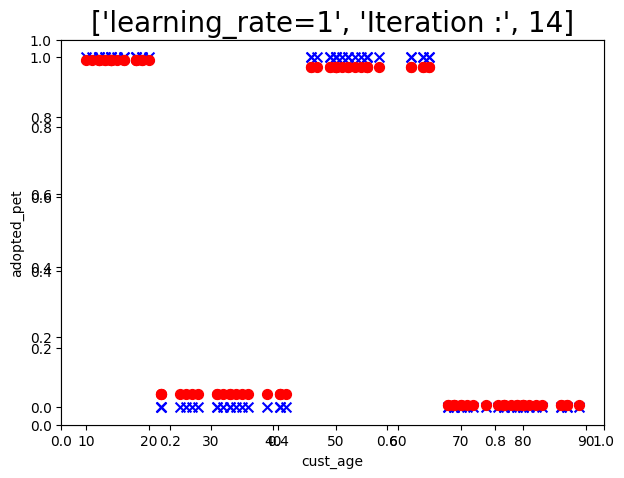

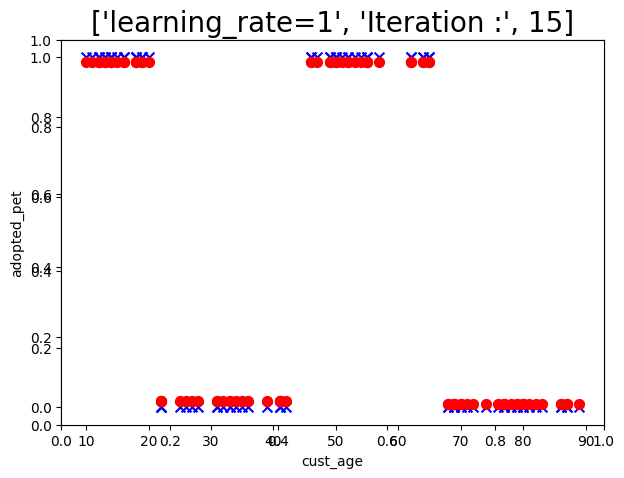

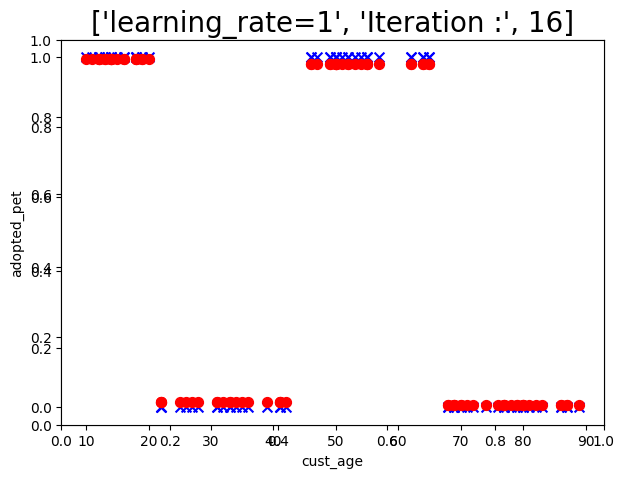

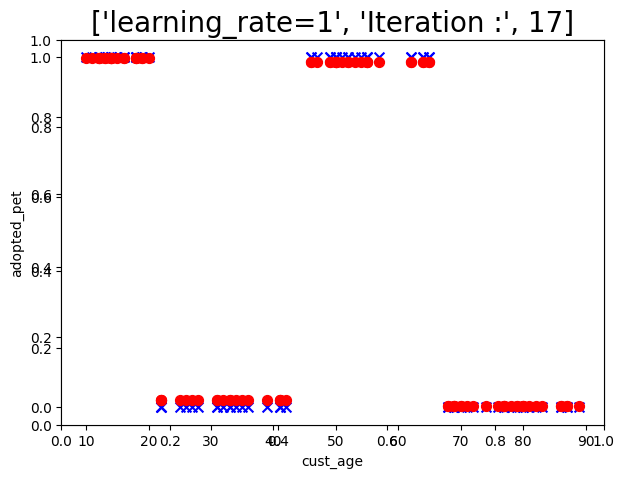

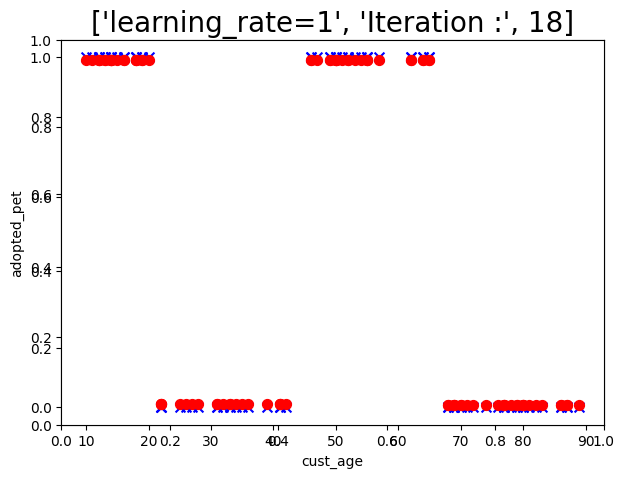

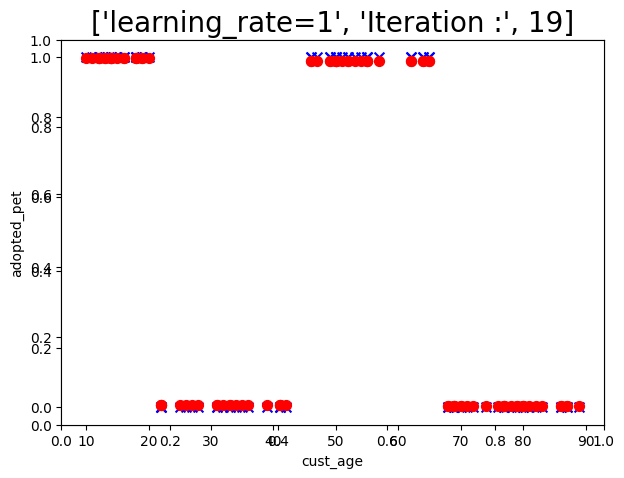

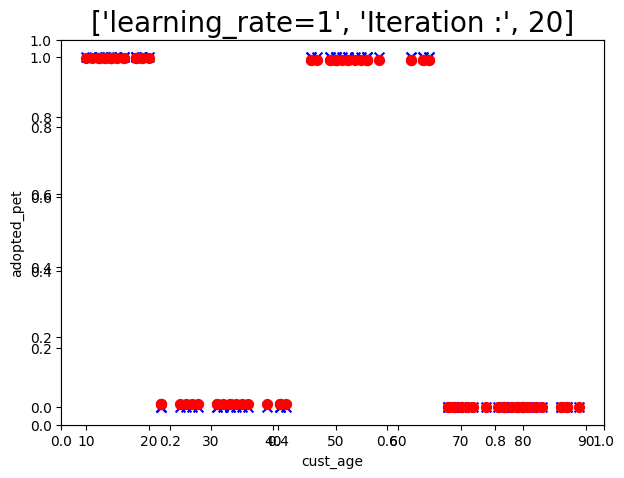

In [35]:
for i in range (1,21):
    
    #Model and predictions 
    boost_model=GradientBoostingClassifier(n_estimators=i,learning_rate=1, max_depth=1)
    boost_model.fit(X,y)
    pets_data["itaration_result"]=boost_model.predict_proba(X)[:,1]
    boost_predict= boost_model.predict(X)
    
    #Graph
    fig = plt.figure()
    plt.rcParams["figure.figsize"] = (7,5)
    plt.title(['learning_rate=1', 'Iteration :', i ], fontsize=20)
    ax1 = fig.add_subplot(111)
    ax1.scatter(pets_data["cust_age"],pets_data["adopted_pet"], s=50, c='b', marker="x")
    ax1.scatter(pets_data["cust_age"],pets_data["itaration_result"], s=50, c='r', marker="o")
    ax1.set_xlabel('cust_age')
    ax1.set_ylabel('adopted_pet')
    
    #SSE and Accuracy
    print("SSE : ", sum((pets_data["itaration_result"] - y)**2))
    accuracy=f1_score(y, boost_predict, average='micro')
    print("Accuracy : ", accuracy)
